<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Word2Vec Skip Gram From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
Notebook 02 counted contexts. Here the vectors are learnt instead, with the skip gram model and negative sampling, written out in torch. Same corpus, so the two can be compared directly at the end.
</div>

## the idea

skip gram takes the centre word and tries to predict the words around it. the prediction itself is useless, we throw the model away. the point is the embedding matrix that comes out of training it.

doing it properly would need a softmax over 3000 words at every step, wich is slow. **negative sampling** replaces that with a much cheaper question:

- take the real pair (centre, context) and push their dot product **up**
- take a few random pairs (centre, random word) and push those **down**

so instead of one 3000 way softmax its a handful of yes or no decisions.

In [1]:
import numpy as np
import collections
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import nltk

torch.manual_seed(0)
nltk.download('brown', quiet=True)
from nltk.corpus import brown

sents = [[w.lower() for w in s if w.isalpha()]
         for s in brown.sents(categories=['news', 'fiction', 'romance', 'adventure'])]
counts = collections.Counter(w for s in sents for w in s)
V = [w for w, n in counts.most_common(3000)]
idx = {w: i for i, w in enumerate(V)}
print("sentences", len(sents), " vocab", len(V))

sentences 17940  vocab 3000


## making the training pairs
every (centre, context) pair inside a window of 3.

In [2]:
WINDOW = 3
pairs = []

for s in sents:
    ids = [idx[w] for w in s if w in idx]
    for i, centre in enumerate(ids):
        lo = max(0, i - WINDOW)
        hi = min(len(ids), i + WINDOW + 1)
        for j in range(lo, hi):
            if i != j:
                pairs.append((centre, ids[j]))

pairs = torch.tensor(pairs)
print("training pairs :", len(pairs))
print("example :", V[pairs[0][0]], "->", V[pairs[0][1]])

training pairs : 1087134
example : the -> fulton


## the noise distribution

the random negatives are not picked uniformly. the word2vec paper raises the frequency to the power 0.75, wich picks common words often but not as often as their raw frequency would.

In [4]:
freq = np.array([counts[w] for w in V], dtype=np.float64) ** 0.75
freq = freq / freq.sum()
neg_dist = torch.tensor(freq, dtype=torch.float)

for w in ['the', 'man', 'school']:
    raw = counts[w] / sum(counts[x] for x in V)
    print(w.ljust(7), " raw share", format(raw, '.4f'), "  after ^0.75", format(freq[idx[w]], '.4f'))

the      raw share 0.0785   after ^0.75 0.0277
man      raw share 0.0021   after ^0.75 0.0018
school   raw share 0.0006   after ^0.75 0.0007


## two embedding tables

one for when a word is the centre and one for when it is the context. only the centre one is kept at the end, thats the standard trick.

In [5]:
D = 100
emb_in  = torch.nn.Embedding(len(V), D)     # centre words, this is the one we keep
emb_out = torch.nn.Embedding(len(V), D)     # context words, thrown away later

torch.nn.init.normal_(emb_in.weight, 0, 0.1)
torch.nn.init.zeros_(emb_out.weight)

print("parameters :", 2 * len(V) * D)

parameters : 600000


## the loss

for a real pair we want `sigmoid(v_centre . v_context)` near 1, for a fake pair near 0. taking logs gives:

```
loss = - log sigmoid(v_c . v_o)  -  sum over negatives of log sigmoid(- v_c . v_neg)
```

In [7]:
def batch_loss(batch, K=5):
    centre, context = batch[:, 0], batch[:, 1]

    negatives = torch.multinomial(neg_dist, len(batch) * K, replacement=True).view(len(batch), K)

    v_c = emb_in(centre)                 # (batch, D)
    v_o = emb_out(context)               # (batch, D)
    v_n = emb_out(negatives)             # (batch, K, D)

    pos = F.logsigmoid((v_c * v_o).sum(1))                          # real pair, push up
    neg = F.logsigmoid(-(v_n * v_c.unsqueeze(1)).sum(2)).sum(1)     # fake pairs, push down
    return -(pos + neg).mean()

In [8]:
opt = torch.optim.Adam(list(emb_in.parameters()) + list(emb_out.parameters()), lr=0.01)
BATCH = 8192
hist = []

for epoch in range(8):
    order = torch.randperm(len(pairs))
    total, steps = 0.0, 0
    for s in range(0, len(pairs), BATCH):
        loss = batch_loss(pairs[order[s:s+BATCH]])
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item(); steps += 1
    hist.append(total / steps)
    print("epoch", epoch, " loss", round(hist[-1], 4))

epoch 0  loss 2.6938


epoch 1  loss 2.4377


epoch 2  loss 2.3711


epoch 3  loss 2.3209


epoch 4  loss 2.2835


epoch 5  loss 2.2577


epoch 6  loss 2.2397


epoch 7  loss 2.2261


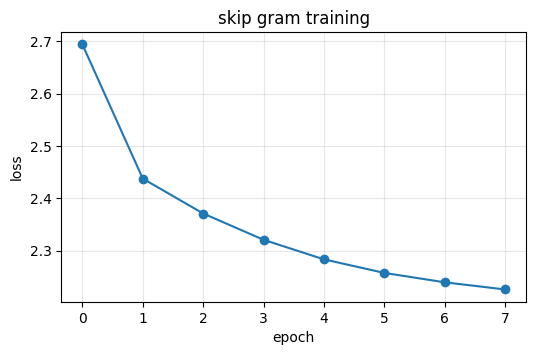

In [10]:
plt.figure(figsize=(6,3.5))
plt.plot(hist, 'o-')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.grid(alpha=.3)
plt.title('skip gram training')
plt.show()

## the vectors it learnt

In [18]:
E = emb_in.weight.detach().numpy()
E = E / np.linalg.norm(E, axis=1, keepdims=True)

def nearest(word, k=6):
    if word not in idx:
        return ["not in vocab"]
    sims = E @ E[idx[word]]
    return [V[i] for i in np.argsort(-sims)[1:k+1]]

for w in ['three', 'red', 'man', 'school', 'city', 'water']:
    print(w.ljust(8), "->", nearest(w))

three    -> ['nine', 'four', 'two', 'five', 'strokes', 'six']
red      -> ['hung', 'white', 'colored', 'lips', 'soft', 'cheeks']
man      -> ['woman', 'bastard', 'shame', 'boy', 'soldier', 'car']
school   -> ['college', 'portland', 'high', 'ohio', 'elected', 'junior']
city     -> ['kansas', 'department', 'welfare', 'rules', 'clerk', 'prison']
water    -> ['glass', 'listening', 'blood', 'mist', 'soil', 'foods']


In [12]:
for w in ['war', 'doctor', 'money', 'music']:
    print(w.ljust(8), "->", nearest(w))

war      -> ['world', 'meanwhile', 'halfway', 'largest', 'french', 'baseball']
doctor   -> ['watching', 'sox', 'elder', 'delegates', 'rooms', 'delphine']
money    -> ['bag', 'rooms', 'current', 'information', 'payroll', 'growing']
music    -> ['susan', 'teaching', 'southern', 'formerly', 'training', 'features']


## does the famous analogy work

`king - man + woman = queen` is the thing everyone shows. trying it here, and a couple of easier ones.

In [13]:
def analogy(a, b, c_, k=4):
    # a is to b as c_ is to ?
    for w in (a, b, c_):
        if w not in idx:
            return [w + " not in vocab"]
    target = E[idx[b]] - E[idx[a]] + E[idx[c_]]
    target = target / np.linalg.norm(target)
    sims = E @ target
    out = [V[i] for i in np.argsort(-sims)[:k+3] if V[i] not in (a, b, c_)]
    return out[:k]

print("man  : woman  ::  he    : ?  ->", analogy('man', 'woman', 'he'))
print("one  : two    ::  three : ?  ->", analogy('one', 'two', 'three'))
print("man  : king   ::  woman : ?  ->", analogy('man', 'king', 'woman'))

man  : woman  ::  he    : ?  -> ['she', 'jane', 'lucy', 'richard']
one  : two    ::  three : ?  -> ['five', 'nine', 'four', 'ten']
man  : king   ::  woman : ?  -> ['john', 'queen', 'golden', 'welcome']


first two are clean, `he` gives `she` and `three` gives five, nine, four.

the king one half worked, `queen` came second behind `john`. honestly more than i expected, because `king` appears 14 times in this corpus and `queen` 9 times. the famous demo used vectors trained on 100 billion words of google news, so 9 occurrences finding the right answer at rank 2 is luck as much as anything.

In [14]:
for w in ['king', 'queen', 'woman', 'man']:
    print(w.ljust(7), counts[w], "occurrences")

king    14 occurrences
queen   9 occurrences
woman   110 occurrences
man     452 occurrences


## count based vs learnt

same corpus, same vocab, same 100 dimensions. the only difference is one counted and one trained.

In [16]:
test_words = ['three', 'red', 'man', 'school', 'water', 'money']

print("skip gram :")
for w in test_words:
    print("  ", w.ljust(8), nearest(w, 4))

skip gram :
   three    ['nine', 'four', 'two', 'five']
   red      ['hung', 'white', 'colored', 'lips']
   man      ['woman', 'bastard', 'shame', 'boy']
   school   ['college', 'portland', 'high', 'ohio']
   water    ['glass', 'listening', 'blood', 'mist']
   money    ['bag', 'rooms', 'current', 'information']


putting the two side by side, neither one wins outright:

| word | count based (nb 02) | skip gram (this one) |
|---|---|---|
| three | four, five, two | nine, four, two, five |
| red | black, gray, blue | hung, white, colored, lips |
| water | still, dark, turned | glass, blood, mist, soil |
| school | high, city, college | college, portland, high, junior |
| doctor | alone, call, stand | watching, sox, elder |

skip gram is better on `water` (glass, blood, mist are all liquid like) and `school`. counting is better on `red`, it returns actual colours while skip gram wanders off to `hung` and `lips`. both are useless on `doctor`.

so on 400 thousand words the method matters less than the size of the corpus.

### recap

- skip gram predicts the context from the centre word, then the model is thrown away and only the embedding table is kept
- negative sampling turns one huge softmax into a few yes or no dot products, thats what makes it fast
- 1 million pairs, 8 epochs, around 10 seconds on a laptop cpu
- analogies work for frequent words, `king - man + woman` put queen at rank 2 wich is half a success
- counting and predicting gave similar quality here, wich matches the known result that skip gram is quietly factorising a co-occurrence matrix anyway